In [24]:
import pandas as pd

pd.set_option('display.width', 250)         # Set max width before wrapping
pd.set_option('display.max_columns', None)  # Show all columns

In [2]:
import statsmodels.api as sm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from patsy import dmatrices

In [3]:
df = sm.datasets.get_rdataset("Guerry", "HistData").data
df = df.dropna()
df['Region'].value_counts()

Region
E    17
N    17
C    17
S    17
W    17
Name: count, dtype: int64

In [4]:
vars = ['Department', 'Lottery', 'Literacy', 'Wealth', 'Region']
y, X = dmatrices("Lottery~Literacy+Wealth+C(Region)", data = df, return_type="dataframe")  # Will automatically one-hot encode categorical variables

In [5]:
X.rank()

,Intercept,C(Region)[T.E],C(Region)[T.N],C(Region)[T.S],C(Region)[T.W],Literacy,Wealth
0,43.0,77.0,34.5,34.5,34.5,41.5,72.0
1,43.0,34.5,77.0,34.5,34.5,62.5,22.0
2,43.0,34.5,34.5,34.5,34.5,3.0,60.0
3,43.0,77.0,34.5,34.5,34.5,58.0,75.0
4,43.0,77.0,34.5,34.5,34.5,79.0,82.0
...,...,...,...,...,...,...,...
80,43.0,34.5,34.5,34.5,77.0,28.5,55.0
81,43.0,34.5,34.5,34.5,77.0,22.0,67.0
82,43.0,34.5,34.5,34.5,34.5,3.0,66.0
83,43.0,77.0,34.5,34.5,34.5,74.5,81.0


# EDA

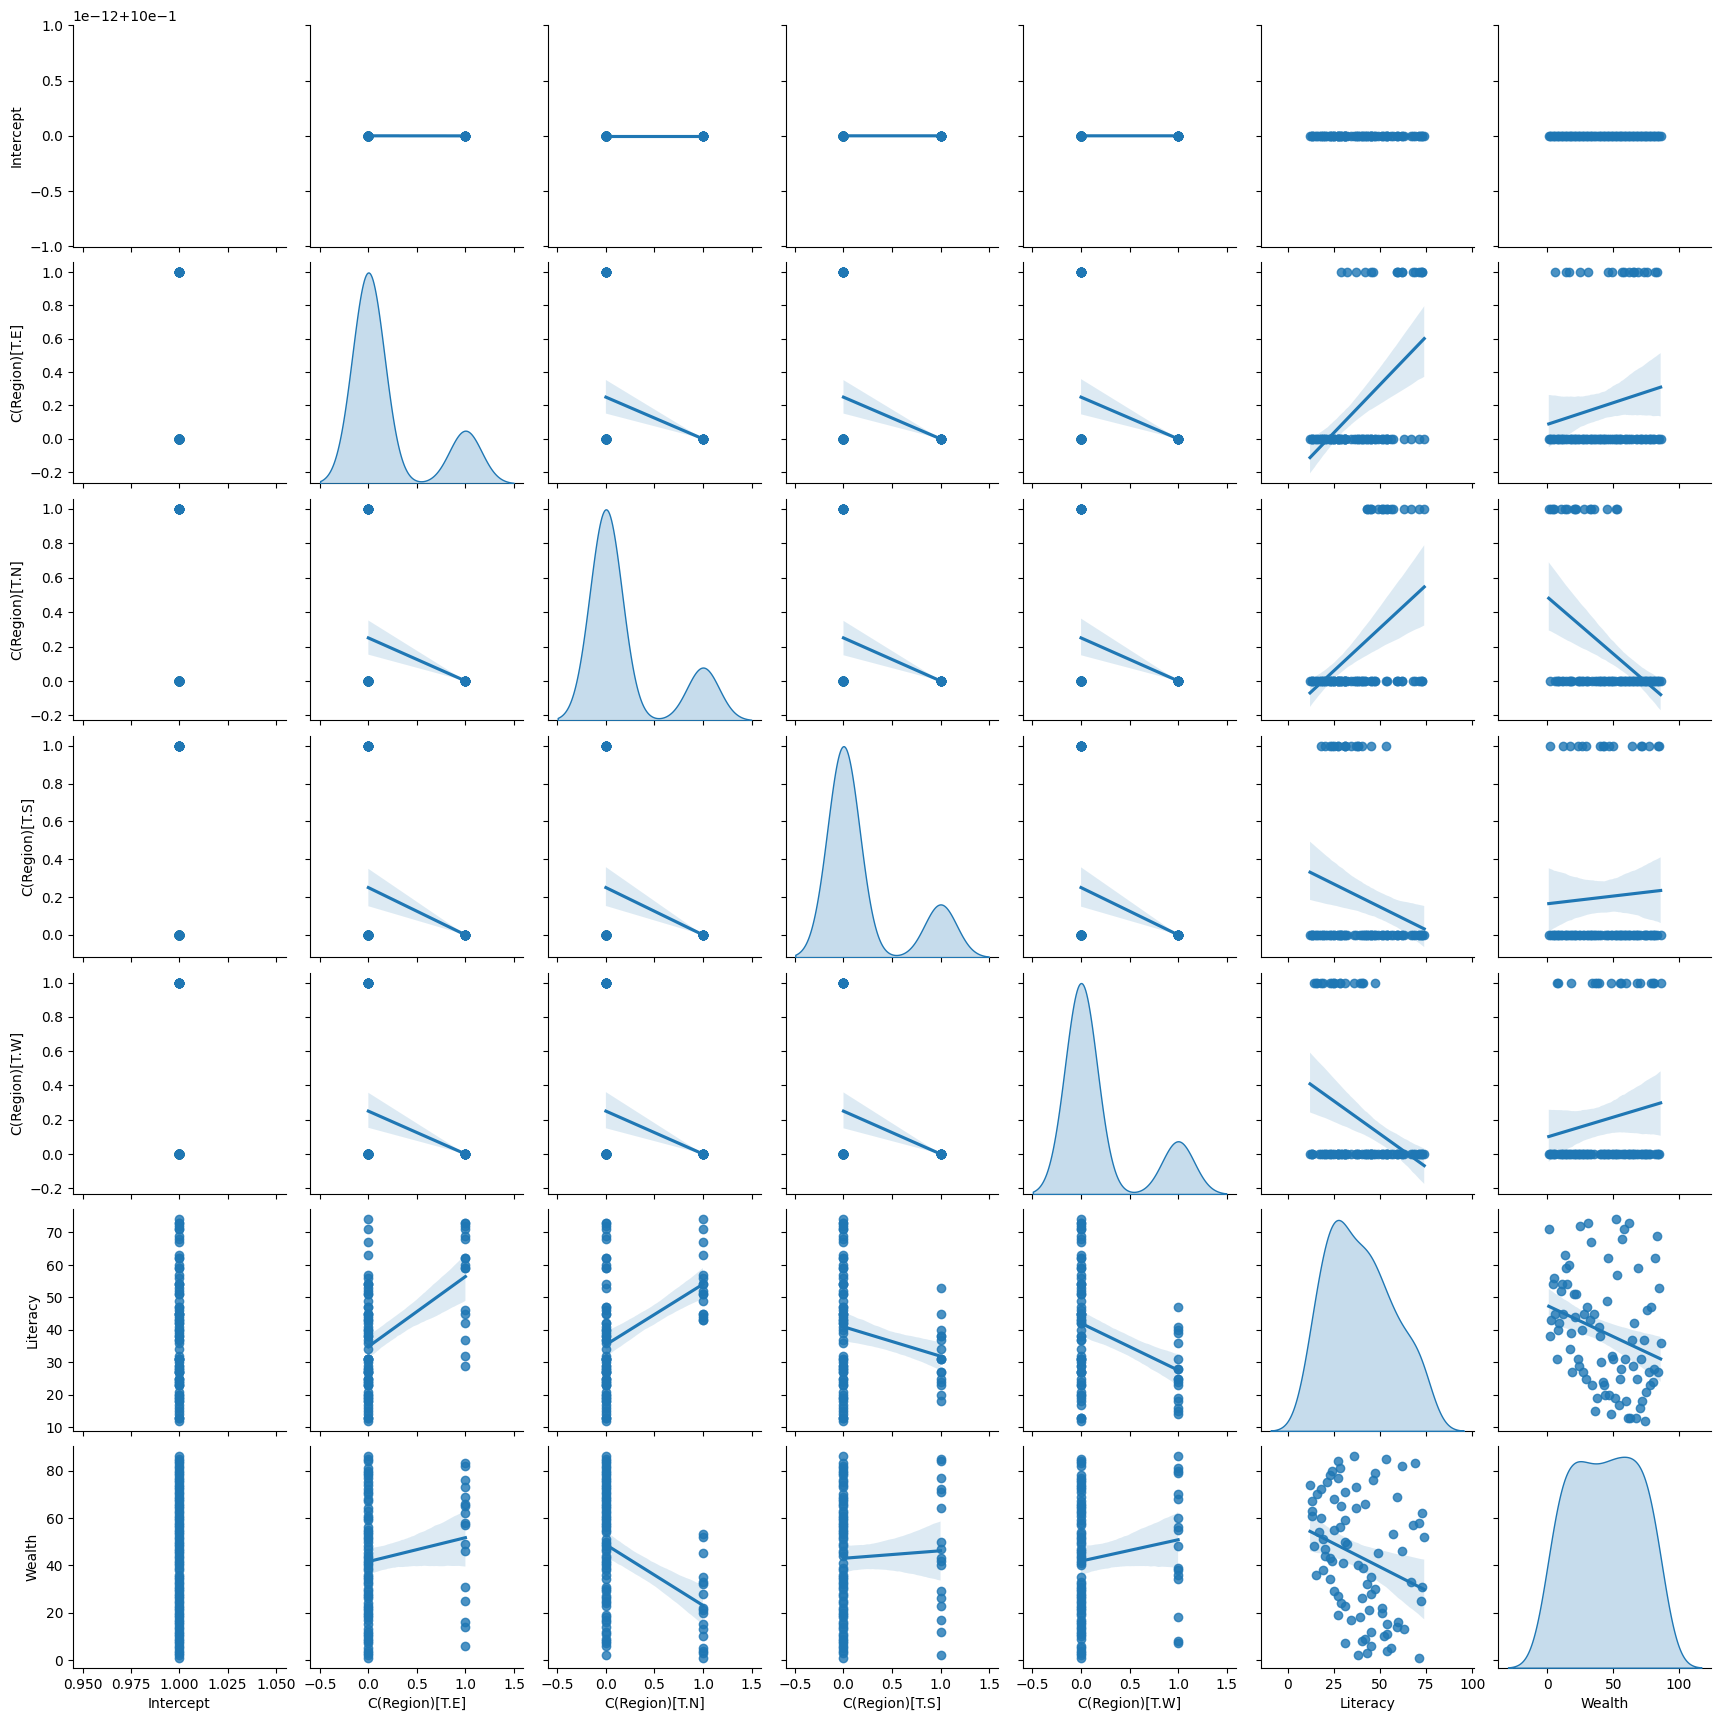

In [6]:
sns.pairplot(data=X, diag_kind="kde", kind="reg")

# Feature analysis and transformation

## Visualize each feature against dependent variable

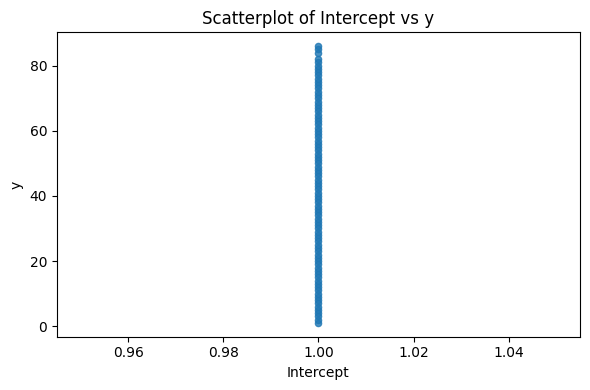

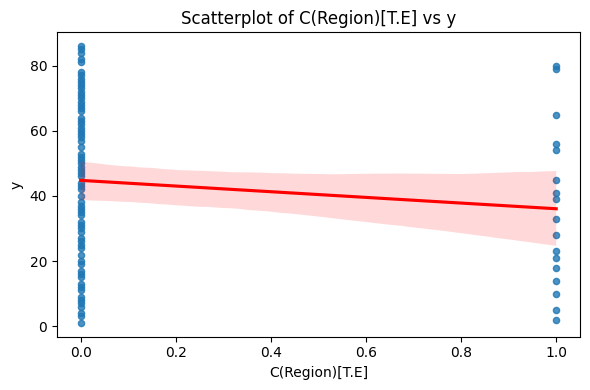

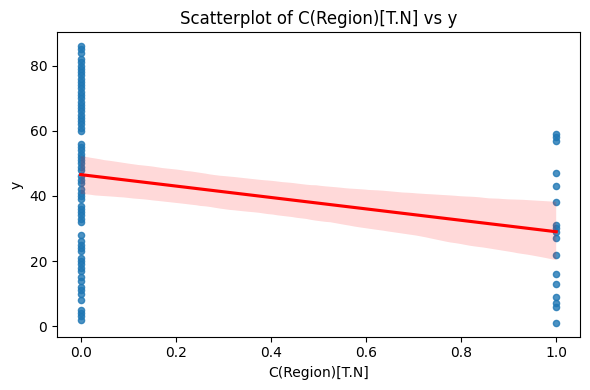

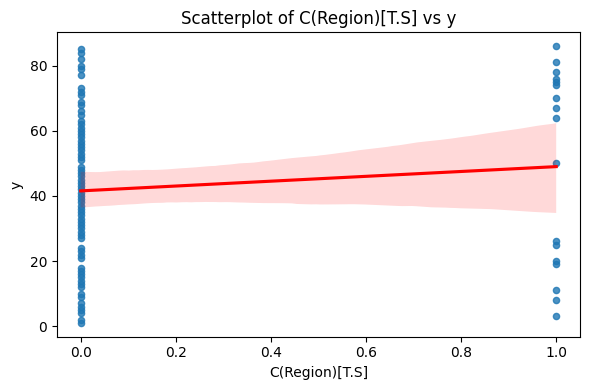

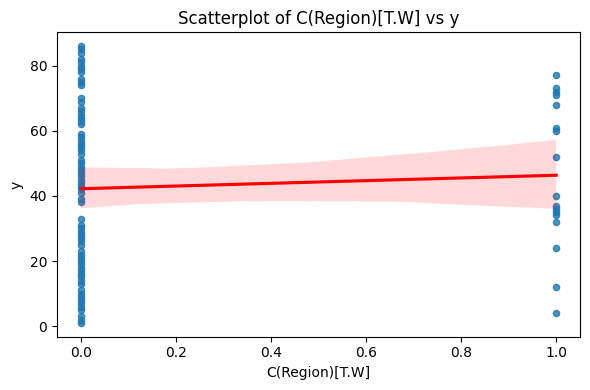

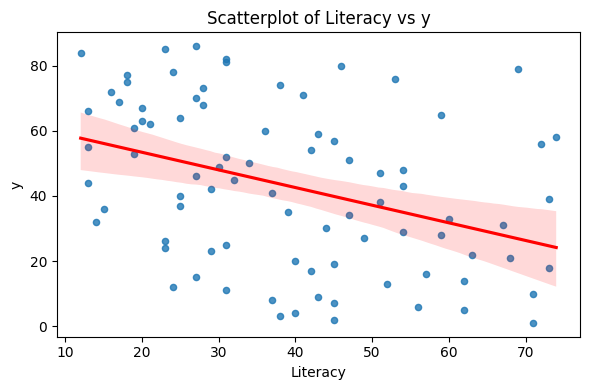

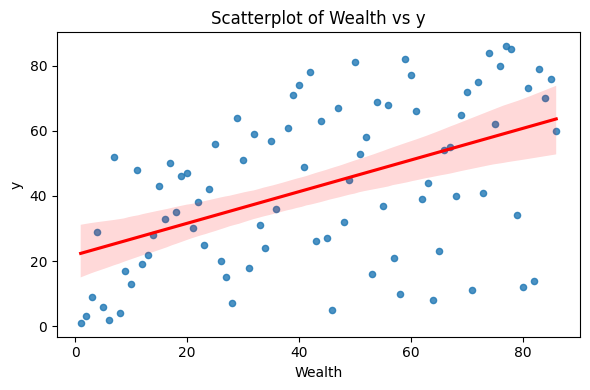

In [50]:
for column in X.columns:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=column, y=y, data=X, ci=95, scatter_kws={"s": 20}, line_kws={"color": "red"})
    plt.title(f'Scatterplot of {column} vs y')
    plt.xlabel(column)
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()

# Standardization

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_vars = ['Literacy', 'Wealth'] # Clearly manually define

X_transformed = pd.concat([X.drop(numerical_vars, axis=1), pd.DataFrame(scaler.fit_transform(X[numerical_vars]), columns=numerical_vars)], axis = 1)

# Specify OLS

In [8]:
ols = sm.OLS(y, X)
res = ols.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     6.636
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           1.07e-05
Time:                        13:12:39   Log-Likelihood:                -375.30
No. Observations:                  85   AIC:                             764.6
Df Residuals:                      78   BIC:                             781.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         38.6517      9.456      4.

In [9]:
ols_std = sm.OLS(y, X_transformed)
res_std = ols_std.fit()
print(res_std.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     6.636
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           1.07e-05
Time:                        13:12:39   Log-Likelihood:                -375.30
No. Observations:                  85   AIC:                             764.6
Df Residuals:                      78   BIC:                             781.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         51.0522      5.768      8.

## Elastic net regularization

In [14]:
ols_reged = ols_std.fit_regularized(alpha=0.1, L1_wt=1, refit=True, maxiter=1000)
print(ols_reged.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     6.622
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           1.06e-05
Time:                        13:13:31   Log-Likelihood:                -375.51
No. Observations:                  85   AIC:                             765.0
Df Residuals:                      79   BIC:                             782.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         48.5468      4.130     11.

In [20]:
print(X_transformed.head())

   Intercept  C(Region)[T.E]  C(Region)[T.N]  C(Region)[T.S]  C(Region)[T.W]  \
0        1.0             1.0             0.0             0.0             0.0   
1        1.0             0.0             1.0             0.0             0.0   
2        1.0             0.0             0.0             0.0             0.0   
3        1.0             1.0             0.0             0.0             0.0   
4        1.0             1.0             0.0             0.0             0.0   

   Literacy    Wealth  
0 -0.123543  1.178832  
1  0.684236 -0.864445  
2 -1.508306  0.698061  
3  0.395744  1.299024  
4  1.722809  1.579474  


# Outlier treatment after model fit

In [30]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns # For example dataset

# Get influence measures
influence = ols_reged.get_influence()

# Create a DataFrame of influence statistics for easier viewing
# These include Cook's Distance, DFFITS, DFBETAS, hat values, and standardized residuals
influence_df = influence.summary_frame()

print("\n--- Top 5 Most Influential Observations (by Cook's Distance) ---")
# Sort by Cook's distance in descending order
print(influence_df.sort_values('cooks_d', ascending=False).head().to_string(line_width = 250))



--- Top 5 Most Influential Observations (by Cook's Distance) ---
    dfb_Intercept  dfb_C(Region)[T.E]  dfb_C(Region)[T.N]  dfb_C(Region)[T.S]  dfb_C(Region)[T.W]  dfb_Literacy  dfb_Wealth   cooks_d  standard_resid  hat_diag  dffits_internal  student_resid    dffits
63      -0.638273            0.413603            0.300903                 inf            0.401697     -0.167338   -0.342853  0.074980       -2.573942  0.073407        -0.724472      -2.652153 -0.746485
41      -0.595343            0.370966            0.247739                 inf           -0.110748     -0.107673   -0.375616  0.070876       -2.414220  0.078445        -0.704368      -2.483213 -0.724497
79      -0.730686            0.508591            0.415415                 inf            0.404402     -0.301547   -0.280493  0.068625       -2.501396  0.071300        -0.693092      -2.571682 -0.712567
49      -0.441503            0.449822            0.125659                 inf            0.366186      0.125745   -0.201330  0

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:929: RuntimeWarning: divide by zero encountered in divide
  dfbetas /= np.sqrt(np.diag(self.results.normalized_cov_params))


## Outlier identification with common methods

## Cooks distance


### What is Cook's Distance?

**Cook's Distance ($D_i$)** measures how much a regression model's **coefficients ($\beta$ values) would change** if a specific observation ($i$) were removed from the dataset. It's a key diagnostic for identifying **influential observations**.

It combines two concepts:
* **Leverage (Hat value):** How "unusual" an observation's predictor (X) values are.
* **Studentized Residual:** How much an observation's response (Y) deviates from its prediction, considering its leverage.

A point needs both **high leverage** and a **large residual** to have a high Cook's Distance.

### When to Use It?

Use Cook's Distance **after fitting a regression model** to:

1.  **Identify Influential Points:** Pinpoint individual data points that disproportionately impact your model's coefficients.
2.  **Assess Model Robustness:** Understand how sensitive your model's results are to single observations.
3.  **Guide Investigation:** Flag points for further review. Is it a data entry error? A measurement issue? Or a genuinely unique, valid observation that reveals something important?

### Interpretation & Thresholds:

While no rule is absolute, common thresholds for $D_i$ are:

* **$D_i > 1$:** Generally considered highly influential.
* **$D_i > \frac{4}{n}$ (where $n$ is the number of observations):** A widely used guideline, especially for larger datasets.

Always complement numerical thresholds with **visual inspection** (e.g., Cook's Distance plots, leverage vs. residual plots) to spot outliers that stand out.

### What to Do with Influential Observations:

**Do NOT simply remove them without careful justification!**

1.  **Verify Data:** Always check for data entry or measurement errors first.
2.  **Consider Robust Methods:** If the observation is valid but truly extreme, use **robust regression methods** (like `statsmodels.RLM`) that are less sensitive to outliers.
3.  **Model Re-evaluation:** The outlier might signal issues with your model specification (e.g., missing variables, uncaptured non-linearity).
4.  **Document & Compare:** If removal is necessary, clearly state your reasons and compare model results with and without the excluded data to show its impact.

---

In [ ]:
# a) Cook's Distance:
# Measures how much the regression coefficients change if the observation is removed.
# A common rule of thumb is that values > 4/n (where n is number of observations)
# or sometimes > 1 are considered influential.
cooks_threshold = 4 / len(y)
print(f"\nCook's Distance threshold (4/n): {cooks_threshold:.4f}")
influential_cooks = influence_df[influence_df['cooks_d'] > cooks_threshold]
print(f"Number of observations with Cook's Distance > {cooks_threshold:.4f}: {len(influential_cooks)}")
print(f"Indices: {influential_cooks.index.tolist()}")



Cook's Distance threshold (4/n): 0.0471
Number of observations with Cook's Distance > 0.0471: 3
Indices: [41, 63, 79]


## Hat values / leverage



### What are Leverage (Hat Values)?

**Leverage**, often denoted as $h_{ii}$ (the $i$-th diagonal element of the hat matrix, $H = X(X'X)^{-1}X'$), measures how "unusual" an individual observation's **predictor (X) values** are compared to the overall distribution of predictor values in the dataset.

* **High Leverage:** An observation with high leverage has predictor values that are far away from the average of the predictors. It sits "alone" in the X-space.
* **Geometric Interpretation:** High leverage points are located at the "extremes" of the predictor space. They have the potential to exert a strong pull on the regression line/plane, but they don't necessarily do so unless they also have a large residual.

### When to Use It?

Use Leverage diagnostics **after fitting a regression model** to:

1.  **Identify Outliers in X-space:** Pinpoint observations that have unusual combinations of predictor values.
2.  **Flag Potentially Influential Points:** High leverage points are "potential" influencers. They have the capacity to pull the regression line towards themselves.
3.  **Guide Investigation:** Examine high-leverage points for data errors or unique characteristics.

### Interpretation & Thresholds:

Leverage values range from $0$ to $1$.

Common rules of thumb for identifying high leverage:

* **$h_{ii} > \frac{2(p+1)}{n}$:** (where $p$ is the number of predictors, $n$ is number of observations). Points exceeding this are often considered high leverage.
* **$h_{ii} > \frac{3(p+1)}{n}$:** A more conservative threshold.
* **Visual Inspection:** Look for points that stand out in scatter plots of predictors or on influence plots.

### What to Do with High Leverage Observations:

**High leverage alone does NOT mean an observation is problematic or should be removed.**

* **Investigate First:** Always check high-leverage points for data errors or unusual circumstances.
* **Context is Key:** A valid high-leverage point might be crucial for understanding the model's behavior at the extremes of your predictor range.
* **Consider Influence:** While high leverage indicates *potential* influence, it doesn't guarantee it. A high leverage point might still fall perfectly on the regression line (small residual), in which case it has low influence (low Cook's Distance).
* **Robust Methods:** If high-leverage points are also influential (high Cook's Distance), consider robust regression methods as an alternative to removal.



In [28]:
# b) Leverage (Hat values):
# Measures how far an observation's predictor values are from the average of the predictors.
# Rule of thumb: values > 2*(p+1)/n or 3*(p+1)/n (where p is number of predictors).
# (p+1 accounts for the intercept)
num_predictors = X_transformed.shape[1] - 1 # exclude constant
leverage_threshold = 2 * (num_predictors + 1) / len(y)
print(f"\nLeverage threshold (2*(p+1)/n): {leverage_threshold:.4f}")
high_leverage = influence_df[influence_df['hat_diag'] > leverage_threshold]
print(f"Number of high-leverage observations (> {leverage_threshold:.4f}): {len(high_leverage)}")
print(f"Indices: {high_leverage.index.tolist()}")



Leverage threshold (2*(p+1)/n): 0.1647
Number of high-leverage observations (> 0.1647): 0
Indices: []


## Studentized residuals

### What are Studentized Residuals?

**Studentized residuals** (often "externally studentized residuals") are a scaled version of a regression model's ordinary residuals. They are calculated by dividing each residual by its estimated standard error, where that standard error is computed *without* including the observation in question.

* **Standardization:** Like standardizing any variable, this scaling makes residuals comparable across different observations and helps identify unusually large deviations.
* **"External" Calculation:** Excluding the observation itself from the standard error calculation means the standard error for that observation's residual is not "contaminated" by the observation's own extreme nature. This makes them more effective for outlier detection than ordinary or standardized residuals.
* **What they indicate:** They measure how much an observation's **actual response (Y) value deviates from its predicted value**, relative to the variability of other residuals. They help identify "outliers in the Y-space" (vertical outliers).

### When to Use It?

Use Studentized Residuals **after fitting a regression model** to:

1.  **Identify Response Outliers:** Pinpoint individual data points where the actual response value is unusually far from what the model predicts.
2.  **Assess Model Fit:** Large studentized residuals suggest the model isn't doing a good job explaining that particular observation.
3.  **Guide Investigation:** Flag points that are poorly explained by the model for further review.

### Interpretation & Thresholds:

Studentized residuals approximately follow a t-distribution. Common thresholds for identifying outliers are based on standard deviations:

* **$| \text{Studentized Residual} | > 2$:** Suggests the observation is outside the typical 95% prediction interval (worth investigating).
* **$| \text{Studentized Residual} | > 3$:** Strongly indicates an outlier (highly unusual deviation).
* **Visual Inspection:** Examine residual plots (e.g., Studentized residuals vs. fitted values) for points that stand out vertically from the cloud of other residuals.

### What to Do with Observations Having Large Studentized Residuals:

**Large studentized residuals alone do NOT mean an observation is influential or should be removed.**

* **Investigate First:** Always check for data entry errors, measurement errors, or unique circumstances.
* **Consider Influence:** A large studentized residual might not be highly influential if the observation has low leverage (i.e., its X-values are close to the mean of X). Use Cook's Distance to assess overall influence.
* **Model Re-evaluation:** A pattern of large residuals (or many large residuals) often points to model misspecification (e.g., omitted variables, wrong functional form, non-normal errors).
* **Robust Methods:** If valid but extreme residuals persist, consider robust regression methods that downweight their influence.

---

In [31]:
# c) Studentized Residuals (External):
# Residuals divided by their standard error, with the current observation excluded
# when calculating the standard error. Helps identify outliers in the dependent variable.
# Rule of thumb: absolute values > 2 (for 95% CI) or > 3 (more strict).
student_resid_threshold = 2.0
outlier_residuals = influence_df[np.abs(influence_df['student_resid']) > student_resid_threshold]
print(f"\nNumber of observations with Studentized Residuals > {student_resid_threshold:.1f}: {len(outlier_residuals)}")
print(f"Indices: {outlier_residuals.index.tolist()}")



Number of observations with Studentized Residuals > 2.0: 3
Indices: [41, 63, 79]


### Influential point visualization

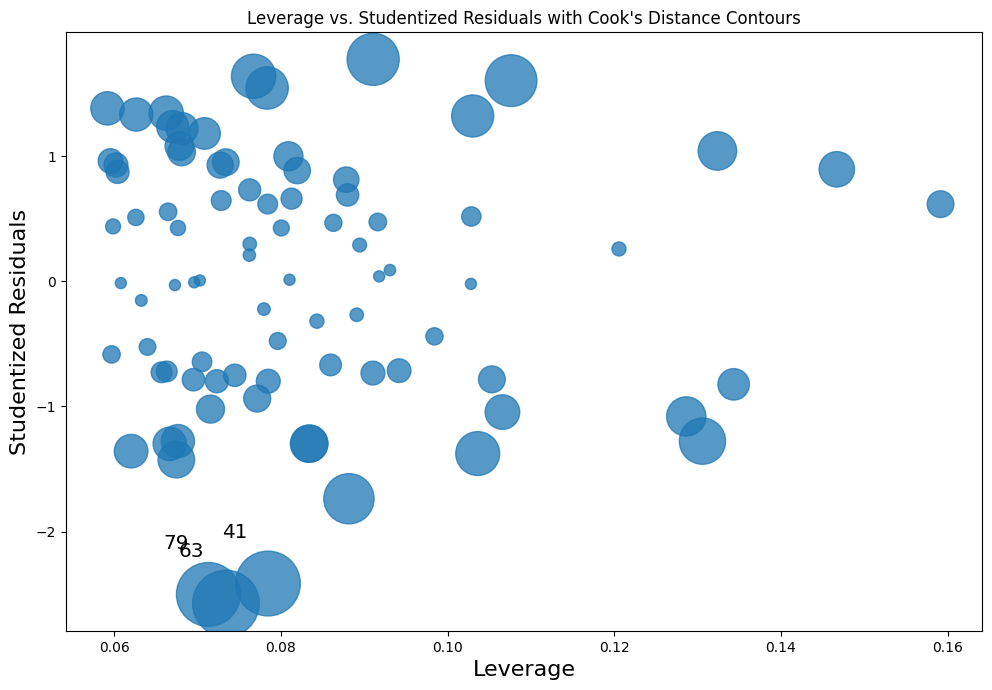

In [ ]:
# --- 4. Visualization of Influential Points ---
# Leverage vs. Normalized Residuals plot with Cook's Distance contours
fig, ax = plt.subplots(figsize=(10, 7))
fig = influence.plot_influence(ax=ax)
fig.tight_layout(pad=1.0)
plt.title("Leverage vs. Studentized Residuals with Cook's Distance Contours")
plt.show()

In [38]:
influence_df.iloc[41,:]
X_transformed.iloc[41,:]

Intercept         1.000000
C(Region)[T.E]    0.000000
C(Region)[T.N]    0.000000
C(Region)[T.S]    0.000000
C(Region)[T.W]    1.000000
Literacy         -0.873623
Wealth            1.459281
Name: 41, dtype: float64

## Outlier exclusion

In [32]:
# Identify indices to exclude. You might combine criteria (e.g., high Cook's AND high Studentized Residuals)
# For this example, let's exclude points with Cook's Distance > 4/n
outlier_indices = influential_cooks.index.tolist()

if outlier_indices:
    print(f"\n--- Excluding {len(outlier_indices)} outliers ---")
    print(f"Indices to exclude: {outlier_indices}")

    # Create new DataFrame without outliers
    Y_cleaned = y.drop(outlier_indices)
    X_cleaned = X_transformed.drop(outlier_indices)

    print(f"Cleaned dataset shape: {Y_cleaned.shape}")

    # --- 6. Refit the Model with Cleaned Data ---
    model_cleaned = sm.OLS(Y_cleaned, X_cleaned)
    results_cleaned = model_cleaned.fit()

    results = sm.OLS(y, X_transformed).fit()
    print("\n--- OLS Model Summary (After Outlier Exclusion) ---")
    print(results_cleaned.summary())

    # Compare coefficients (optional)
    print("\n--- Comparison of Coefficients ---")
    print("Original Model Coefficients:")
    print(results.params)
    print("\nCleaned Model Coefficients:")
    print(results_cleaned.params)

else:
    print("\nNo outliers identified based on the chosen Cook's Distance threshold. No exclusion performed.")


--- Excluding 3 outliers ---
Indices to exclude: [41, 63, 79]
Cleaned dataset shape: (82, 1)

--- OLS Model Summary (After Outlier Exclusion) ---
                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     10.80
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           1.25e-08
Time:                        13:31:14   Log-Likelihood:                -352.16
No. Observations:                  82   AIC:                             718.3
Df Residuals:                      75   BIC:                             735.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|     

# Visualizations

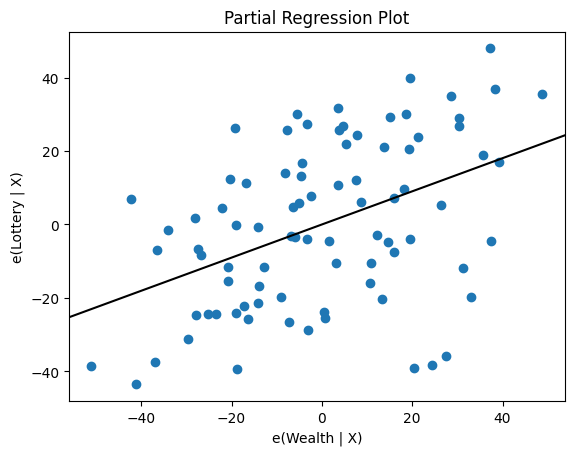

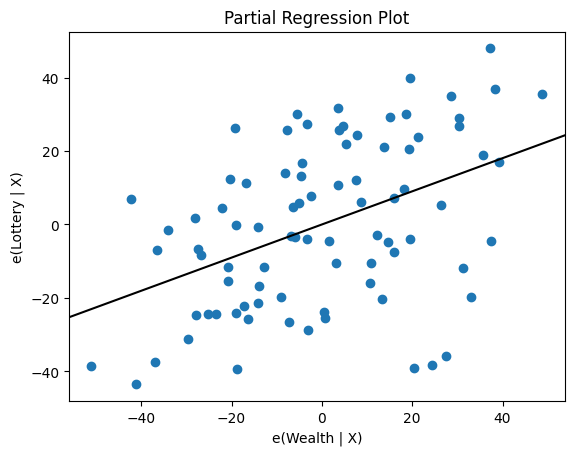

In [ ]:
sm.graphics.plot_partregress('Lottery', 'Wealth', ['Region', 'Literacy'],
                             data=df, obs_labels=False)